## U-Net Analytics

Imports

In [5]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
import os
from PIL import Image
from torchvision import transforms
import json
import numpy as np
import time
import matplotlib.pyplot as plt


Dataset

In [2]:
class PavementDataset(Dataset):
    def __init__(self, dataset_root, list_txt, transform=None):
        self.dataset_root = dataset_root
        self.transform = transform
        self.pairs = []

        with open(list_txt, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 2:
                    img_path = os.path.join(dataset_root, parts[0])
                    mask_path = os.path.join(dataset_root, parts[1])
                    self.pairs.append((img_path, mask_path))
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, index):
        img_path, mask_path = self.pairs[index]

        image = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)
        
        return image, mask

Define Model

In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.bottleneck = DoubleConv(256, 512)
        self.pool = nn.MaxPool2d(2)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))

        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))

        return torch.sigmoid(self.out(d1))

Test Model

In [4]:
def test(model, test_loader, device):
    criterion = nn.BCELoss()
    print(f"Starting Test on {device}...")

    test_metrics = {'tp': 0, 'tn': 0, 'fp': 0, 'fn': 0, 'loss': 0.0}

    with torch.no_grad():

        for images, masks in test_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)

            preds = (outputs > 0.5).float()

            test_metrics['loss'] += loss.item()
            test_metrics['tp'] += torch.sum((preds == 1) & (masks == 1)).item()
            test_metrics['tn'] += torch.sum((preds == 0) & (masks == 0)).item()
            test_metrics['fp'] += torch.sum((preds == 1) & (masks == 0)).item()
            test_metrics['fn'] += torch.sum((preds == 0) & (masks == 1)).item()

        def calc_stats(m, loader):
            total_px = m['tp'] + m['tn'] + m['fp'] + m['fn']
            acc = (m['tp'] + m['tn']) / (total_px + 1e-9)
            prec = m['tp'] / (m['tp'] + m['fp'] + 1e-9)
            rec = m['tp'] / (m['tp'] + m['fn'] + 1e-9)
            f1 = 2 * (prec * rec) / (prec + rec + 1e-9)
            return acc, prec, rec, f1, m['loss'] / len(loader)

        te_acc, te_prec, te_rec, te_f1, te_loss = calc_stats(test_metrics, test_loader)
        print("--- Results ---")
        print(f"Train Loss: {te_loss:.4f}\nTest Acc: {te_acc:.5f}\nTest Prec: {te_prec:.5f}\nTest Rec: {te_rec:.5f}\nTest F1: {te_f1:.5f}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = './checkpoints/Early_Stop/best_unet_model.pth' 
model = UNet(in_channels=3).to(device)
checkpoint = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(checkpoint)
model.eval()
transform = transforms.Compose([
    transforms.Resize((360, 640)),
    transforms.ToTensor(),
])
test_ds = PavementDataset("../CRACK500", "../CRACK500/test.txt", transform=transform)
test_loader = DataLoader(test_ds, batch_size=4, shuffle=True)
start_time = time.perf_counter()
test(model, test_loader, device)
end_time = time.perf_counter()
total_time = end_time - start_time
num_images = len(test_ds)
print(f"Total Time: {total_time}\nAverage Time: {total_time/num_images}\nThroughput: {num_images/total_time}")

Starting Test on cuda...
--- Results ---
Train Loss: 0.0901
Test Acc: 0.96718
Test Prec: 0.78269
Test Rec: 0.57048
Test F1: 0.65995
Total Time: 85.3845521180001
Average Time: 0.07596490401957304
Throughput: 13.163973717946659


Training Loss

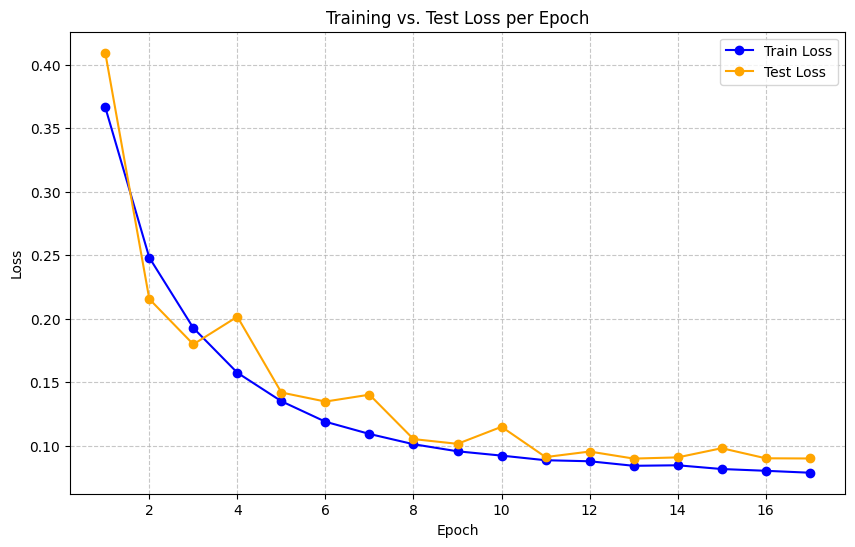

In [7]:
with open('./results/Early_Stop/unet_analytics_earlystop.json', 'r') as f:
    data = json.load(f)

epochs = [item['epoch'] for item in data]
train_loss = [item['train']['loss'] for item in data]
test_loss = [item['test']['loss'] for item in data]

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Train Loss', marker='o', linestyle='-', color='blue')
plt.plot(epochs, test_loss, label='Test Loss', marker='o', linestyle='-', color='orange')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Test Loss per Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Overfitting Loss

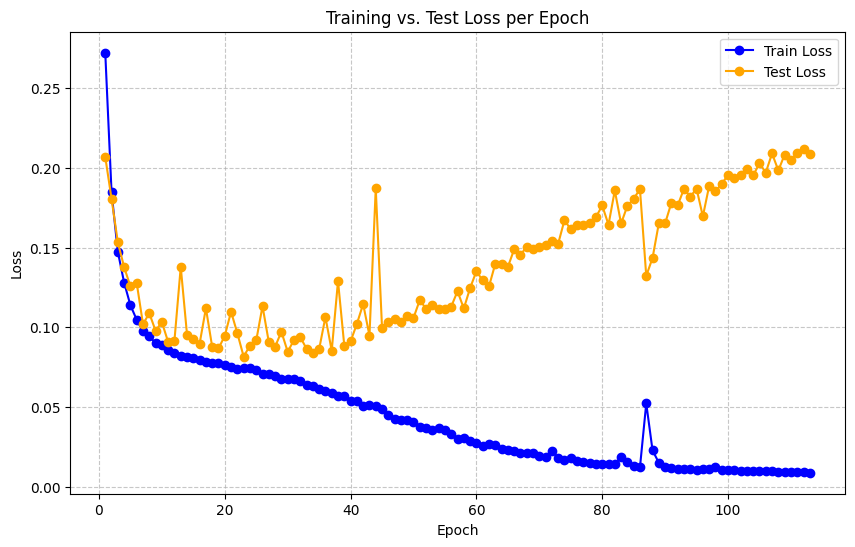

: 

In [ ]:
with open('./results/Overfitted/unet_analytics_OverFitted.json', 'r') as f:
    data = json.load(f)

epochs = [item['epoch'] for item in data]
train_loss = [item['train']['loss'] for item in data]
test_loss = [item['test']['loss'] for item in data]

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, label='Train Loss', marker='o', linestyle='-', color='blue')
plt.plot(epochs, test_loss, label='Test Loss', marker='o', linestyle='-', color='orange')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs. Test Loss per Epoch')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()